In [ ]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

from sklearn.preprocessing import MinMaxScaler

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

x_train shape: (60000, 28, 28)
x_test shape : (10000, 28, 28)
y_train shape: (60000,)
y_test shape : (10000,)


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


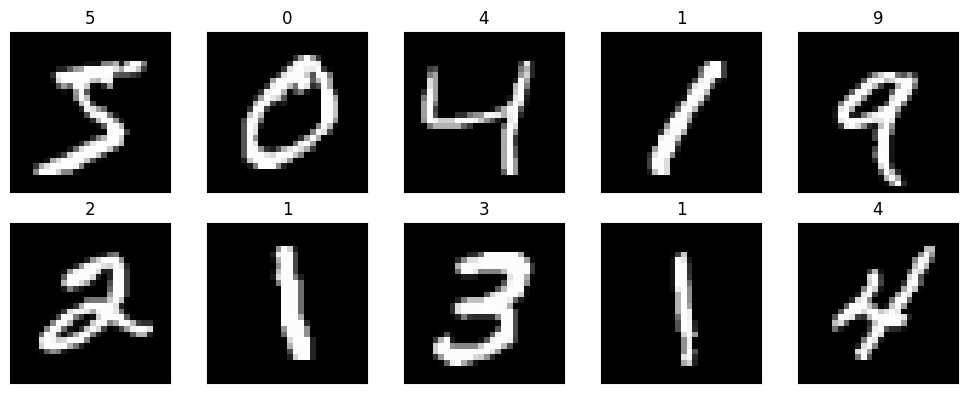

In [ ]:
class_names = [
    '0', '1', '2', '3', '4',
    '5', '6', '7', '8', '9'
]

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(class_names[np.argmax(y_train[i])])

plt.tight_layout()
plt.show()

In [ ]:
inpt_dim = (28, 28, 1)

inpt_img = Input(shape=inpt_dim)

# First Convolutional Layer
c11 = Conv2D(
    32,
    (3, 3),
    activation='relu'
)(inpt_img)

# Pooling
p12 = MaxPooling2D(
    pool_size=(2, 2)
)(c11)

# Batch Normalization
bn13 = BatchNormalization()(p12)


# Second Convolutional Layer
c14 = Conv2D(
    64,
    (3, 3),
    activation='relu'
)(bn13)

# Pooling
p15 = MaxPooling2D(
    pool_size=(2, 2)
)(c14)

# Batch Normalization
bn16 = BatchNormalization()(p15)


# Flatten
f17 = Flatten()(bn16)

# Dense + Dropout
do18 = Dropout(0.5)(f17)

d19 = Dense(
    128,
    activation='relu'
)(do18)

do110 = Dropout(0.2)(d19)

d111 = Dense(
    64,
    activation='relu'
)(do110)

do112 = Dropout(0.1)(d111)

# Output Layer
output = Dense(
    10,
    activation='softmax'
)(do112)


# Create Model
classifier = Model(
    inpt_img,
    output
)

classifier.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,034 (910.29 KB)

 Trainable params: 232,842 (909.54 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
opt = RMSprop(
    learning_rate=0.001
)

classifier.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_delta=1e-4,
    mode='min',
    verbose=1
)

In [ ]:
stop_alg = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
checkpoint_filepath = 'mnist_cnn_best.keras'

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
hist = classifier.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    callbacks=[
        stop_alg,
        reduce_lr,
        model_checkpoint
    ],
    shuffle=True,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8609 - loss: 0.4535
Epoch 1: val_accuracy improved from None to 0.49217, saving model to mnist_cnn_best.keras

Epoch 1: finished saving model to mnist_cnn_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 110ms/step - accuracy: 0.9313 - loss: 0.2295 - val_accuracy: 0.4922 - val_loss: 1.8900 - learning_rate: 0.0010
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9722 - loss: 0.0950
Epoch 2: val_accuracy improved from 0.49217 to 0.98867, saving model to mnist_cnn_best.keras

Epoch 2: finished saving model to mnist_cnn_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 109ms/step - accuracy: 0.9728 - loss: 0.0938 - val_accuracy: 0.9887 - val_loss: 0.0385 - learning_rate: 0.0010
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9793 - loss: 0.0713
Epoch 3: val_accuracy improved from 0.98867 to 0.98883, saving model to mnist_cnn_best.keras

Epoch 3: finished saving model to mnist_cnn_best.keras
422/

In [ ]:
test_loss, test_acc = classifier.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("========== Test Results ==========")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Accuracy %:", test_acc * 100)

313/313 - 3s - 9ms/step - accuracy: 0.9935 - loss: 0.0241
========== Test Results ==========
Test Loss: 0.02407565712928772
Test Accuracy: 0.9934999942779541
Test Accuracy %: 99.34999942779541


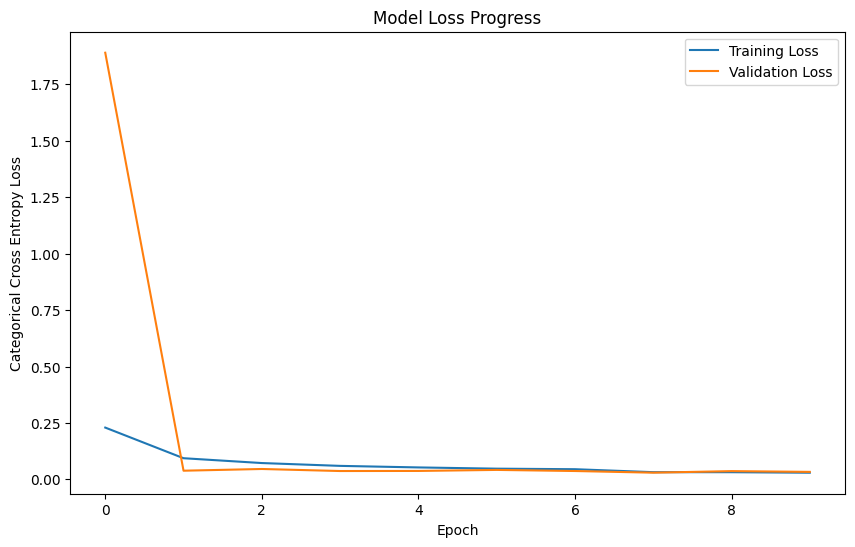

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist.history['loss'],
    label='Training Loss'
)

plt.plot(
    hist.history['val_loss'],
    label='Validation Loss'
)

plt.title('Model Loss Progress')
plt.ylabel('Categorical Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.show()

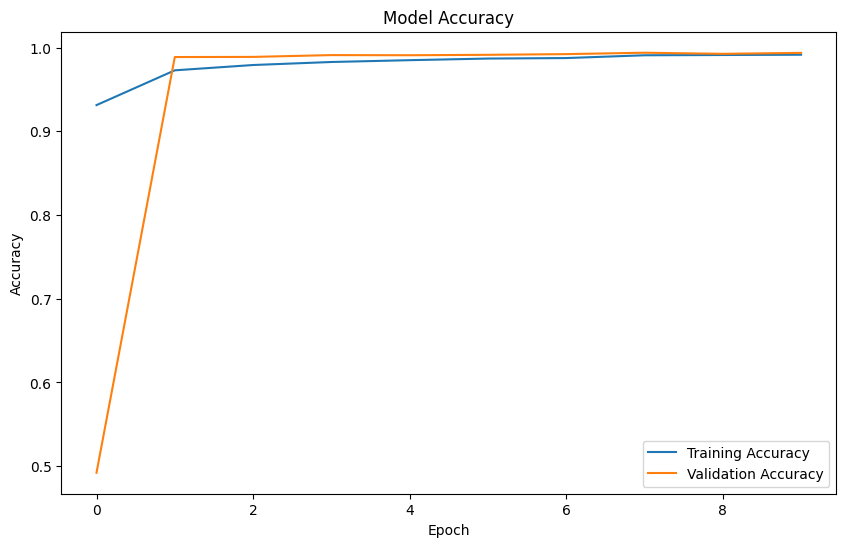

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    hist.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

plt.show()

In [ ]:
y_hat = classifier.predict(x_test)

y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      0.99      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 978    0    1    0    0    0    0    1    0    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0    1 1026    0    0    0    0    5    0    0]
 [   0    0    0 1004    0    5    0    0    1    0]
 [   0    0    0    0  980    0    0    0    1    1]
 [   1    0    0    4    0  884    1    0    0    2]
 [   4    2    0    0    1    2  947    0    2    0]
 [   0    3    1    0    0    0    0 1024    0    0]
 [   1    1    2    0    0    0    0    1  967    2]
 [   0    0    0    0   10    4    0    5    0  990]]


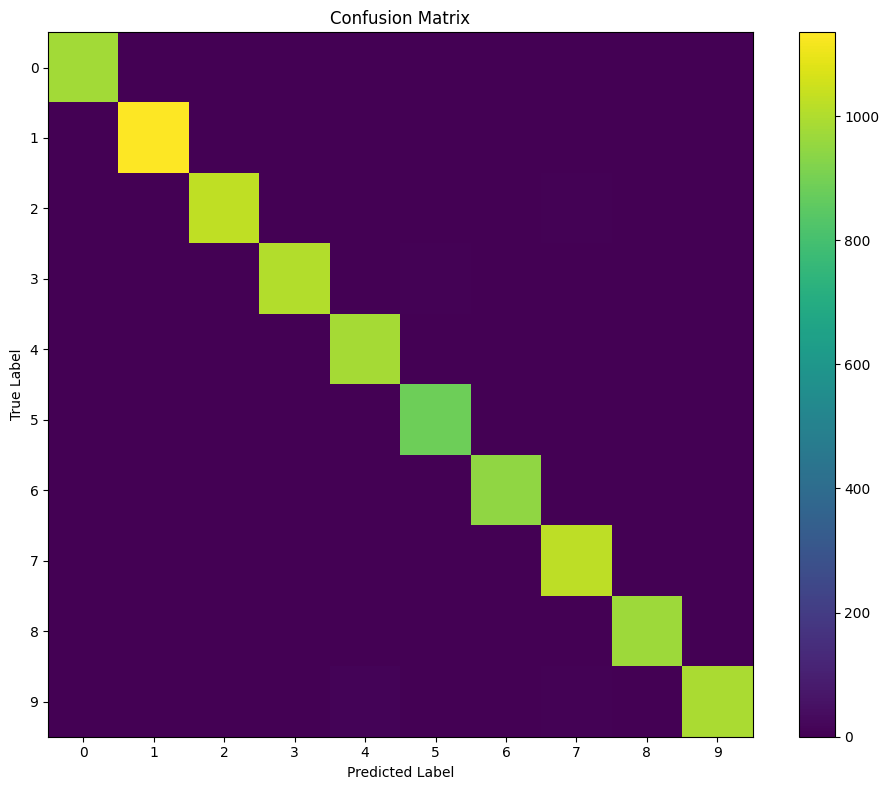

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(10), class_names)
plt.yticks(range(10), class_names)

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

ber = 1 - balanced_acc

print("Balanced Accuracy:", balanced_acc)
print("BER:", ber)

Balanced Accuracy: 0.9933808677512708
BER: 0.0066191322487292314


In [ ]:
classifier.save("mnist_cnn_final.keras")

In [ ]:
ModelCheckpoint(
    filepath='mnist_cnn_best.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [ ]:
best_model = keras.models.load_model("mnist_cnn_best.keras")

In [ ]:
test_loss, test_acc = best_model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("========== Best Model ==========")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Accuracy %:", test_acc * 100)

313/313 - 5s - 15ms/step - accuracy: 0.9935 - loss: 0.0241
========== Best Model ==========
Test Loss: 0.02407565712928772
Test Accuracy: 0.9934999942779541
Test Accuracy %: 99.34999942779541


In [ ]:
y_hat = best_model.predict(x_test)

y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_test, axis=1)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      0.99      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 978    0    1    0    0    0    0    1    0    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0    1 1026    0    0    0    0    5    0    0]
 [   0    0    0 1004    0    5    0    0    1    0]
 [   0    0    0    0  980    0    0    0    1    1]
 [   1    0    0    4    0  884    1    0    0    2]
 [   4    2    0    0    1    2  947    0    2    0]
 [   0    3    1    0    0    0    0 1024    0    0]
 [   1    1    2    0    0    0    0    1  967    2]
 [   0    0    0    0   10    4    0    5    0  990]]


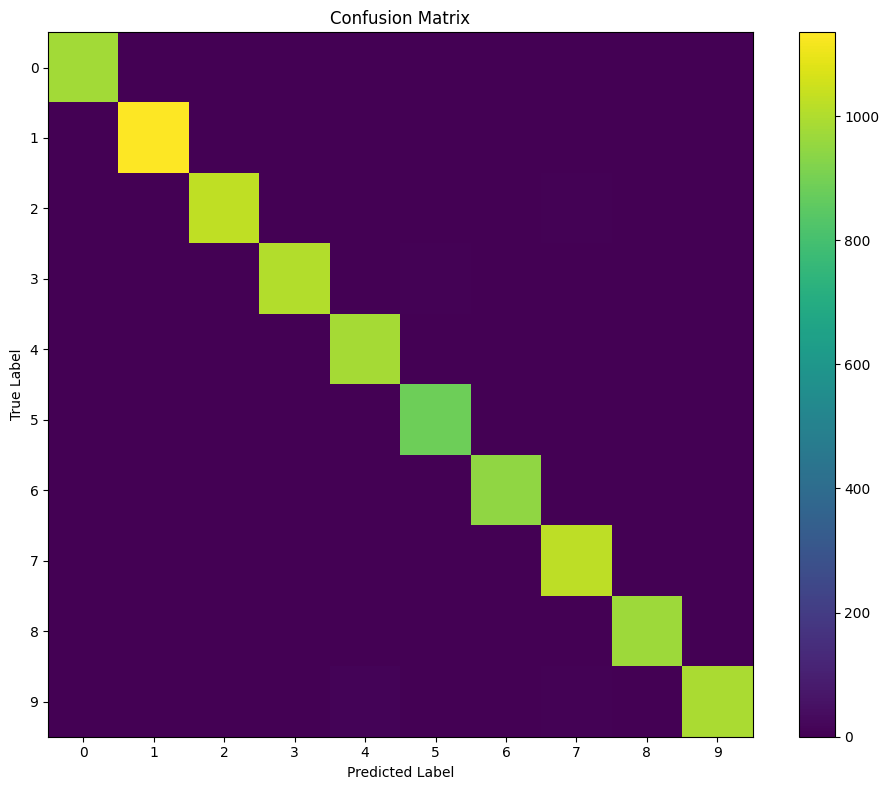

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(10), class_names)
plt.yticks(range(10), class_names)

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

ber = 1 - balanced_acc

print("Balanced Accuracy:", balanced_acc)
print("BER:", ber)

Balanced Accuracy: 0.9933808677512708
BER: 0.0066191322487292314


In [ ]:
cnn_layer = None

for layer in best_model.layers:
    if isinstance(layer, Conv2D):
        cnn_layer = layer
        break

print("First CNN layer:", cnn_layer.name)

First CNN layer: conv2d_3


In [ ]:
w = cnn_layer.get_weights()[0]

print("Filter shape:", w.shape)

Filter shape: (3, 3, 1, 32)


In [ ]:
scaler = MinMaxScaler()

w_scaled = scaler.fit_transform(
    w.reshape(-1, 1)
)

w_scaled = w_scaled.reshape(w.shape)

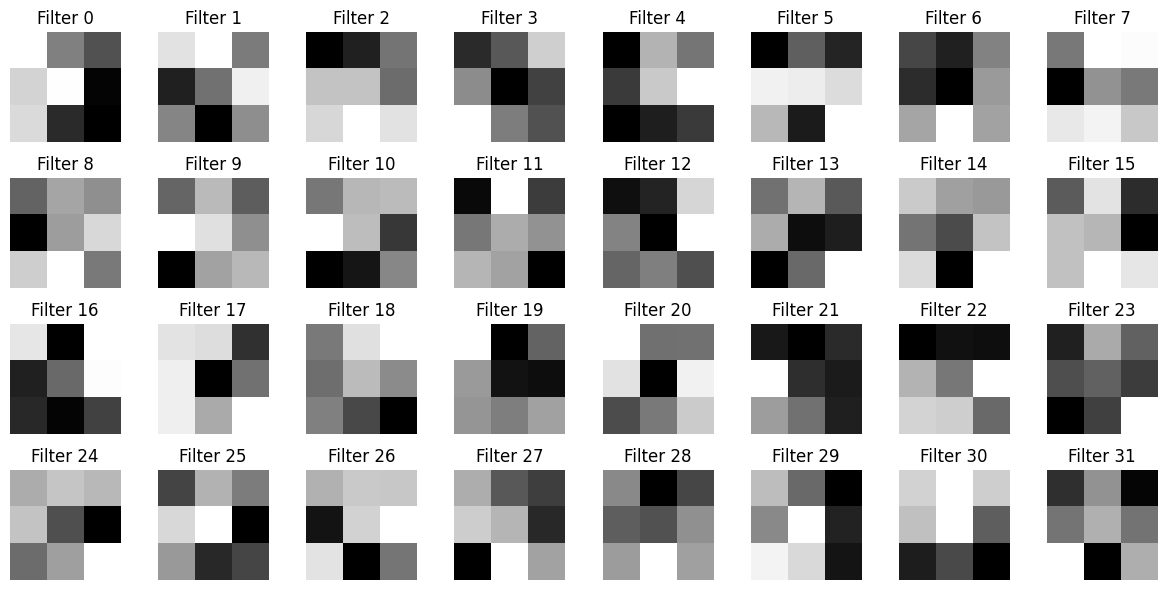

In [ ]:
fig, axs = plt.subplots(
    4,
    8,
    figsize=(12, 6)
)

axs = axs.ravel()

for i in range(w_scaled.shape[-1]):

    filter_img = w_scaled[:, :, 0, i]

    axs[i].imshow(
        filter_img,
        cmap='gray'
    )

    axs[i].set_title(
        "Filter " + str(i)
    )

    axs[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("========== FINAL RESULTS ==========")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Balanced Accuracy: {balanced_acc * 100:.2f}%")
print(f"BER: {ber:.4f}")

========== FINAL RESULTS ==========
Test Accuracy: 99.35%
Balanced Accuracy: 99.34%
BER: 0.0066
